## Problem Statement - The primary problem identified is the need to reduce response times and minimize property loss through predictive analysis.


## 1.We start by importing necessary Python libraries used throughout the project:

- **pandas** and **numpy** for data handling and numerical operations.
- **matplotlib** and **seaborn** for visualization.
- **sklearn** for preprocessing, feature selection, model building, and evaluation.
- **xgboost** for a powerful boosting-based classifier.
   
   
   These tools will help us with each phase of the data mining pipeline — from preprocessing and visualization to modeling and interpretation.


In [101]:
## Step 1: Import Libraries
# Import required libraries for data processing, modeling, and visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

## 2.Loading and Preprocessing Data

We load the Boston Fire Department dataset and begin initial preprocessing:

- Dropping unnecessary columns.
- Parse date-time fields for time-based features.
- Create a binary classification target `Fire` — `1` for high property loss (> $300), `0` otherwise.
- Handleng missing values using median imputation for numerical fields like `Total Loss`.

This step ensures the data is clean, structured, and ready for analysis.


In [102]:
# ## Step 2: Load and Preprocess Data
# Load the dataset, select relevant columns, handle missing values, and create the target variable.
data = pd.read_csv('2012-bostonfireincidentopendata.csv', low_memory=False)


In [103]:
# Select relevant columns
columns_to_keep = ['Alarm Date', 'Incident Type', 'District', 'Zip', 'Property Use', 'Estimated Property Loss', 'Estimated Content Loss']
data = data[columns_to_keep]

In [104]:
# Handle missing values
data['Estimated Property Loss'] = data['Estimated Property Loss'].fillna(data['Estimated Property Loss'].median())
data['Estimated Content Loss'] = data['Estimated Content Loss'].fillna(data['Estimated Content Loss'].median())

In [105]:
# Create target variable
data['Total Loss'] = data['Estimated Property Loss'] + data['Estimated Content Loss']
data['Fire'] = np.where(data['Total Loss'] > 300, 1, 0)


In [106]:
# Drop unnecessary columns
data = data.drop(['Estimated Property Loss', 'Estimated Content Loss', 'Total Loss'], axis=1)

In [107]:
# Convert Alarm Date to datetime
data['Alarm Date'] = pd.to_datetime(data['Alarm Date'])


## 3. Feature Engineering

We enhance the dataset by deriving new features that may influence emergency response:

- **Date Features**: Extract month, day of the week, and a binary weekend flag from the alarm timestamp.
- **ZIP Code Frequency**: Count incidents by ZIP code to capture location-based trends.
- **Label Encoding**: Convert categorical fields into numerical values for compatibility with ML models.

Feature engineering adds domain-relevant context to improve model accuracy.


In [108]:
# ## Step 3: Feature Engineering
# Extract time-based features from Alarm Date and aggregate incidents by Zip.
data['Month'] = data['Alarm Date'].dt.month
data['DayOfWeek'] = data['Alarm Date'].dt.dayofweek
data['IsWeekend'] = data['DayOfWeek'].isin([5, 6]).astype(int)

In [109]:
# Aggregate incident counts by ZIP
incident_counts = data.groupby('Zip').size().reset_index(name='IncidentCount')
data = data.merge(incident_counts, on='Zip', how='left')


In [110]:
# Encode categorical variables
le = LabelEncoder()
categorical_cols = ['Incident Type', 'District', 'Zip', 'Property Use']
for col in categorical_cols:
    data[col] = le.fit_transform(data[col].astype(str))

## 4. Exploratory Data Analysis (EDA)

We explore the dataset visually to understand variable distributions, relationships, and potential predictive signals:

- **Bar plots** for categorical distributions.
- **Box plots** to examine variations in property loss across categories.
- **Heatmaps** and **pairplots** to inspect correlations and feature interactions.

EDA is crucial for discovering patterns and deciding which variables are likely to be useful predictors.


In [111]:
# ## Step 4: Exploratory Data Analysis
# Visualize data to understand distributions, trends, and relationships.

# Class distribution
print("Class Distribution:")
print(data['Fire'].value_counts(normalize=True))

Class Distribution:
Fire
0    0.965648
1    0.034352
Name: proportion, dtype: float64


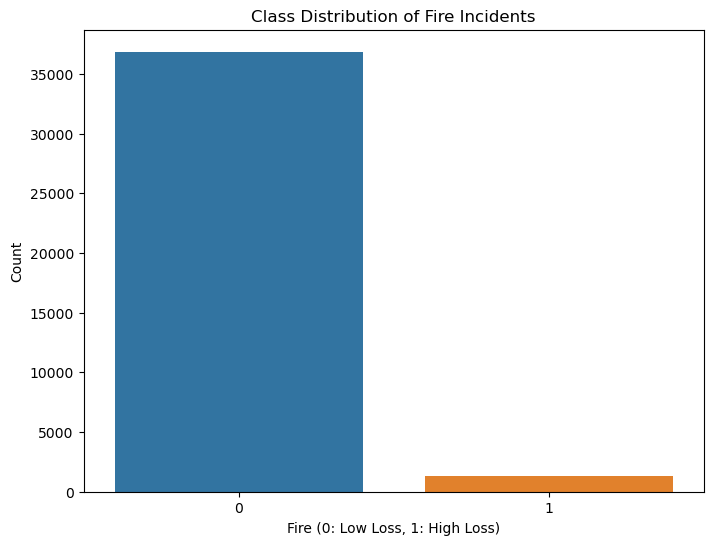

In [112]:
# Plot class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Fire', data=data)
plt.title('Class Distribution of Fire Incidents')
plt.xlabel('Fire (0: Low Loss, 1: High Loss)')
plt.ylabel('Count')
plt.show()

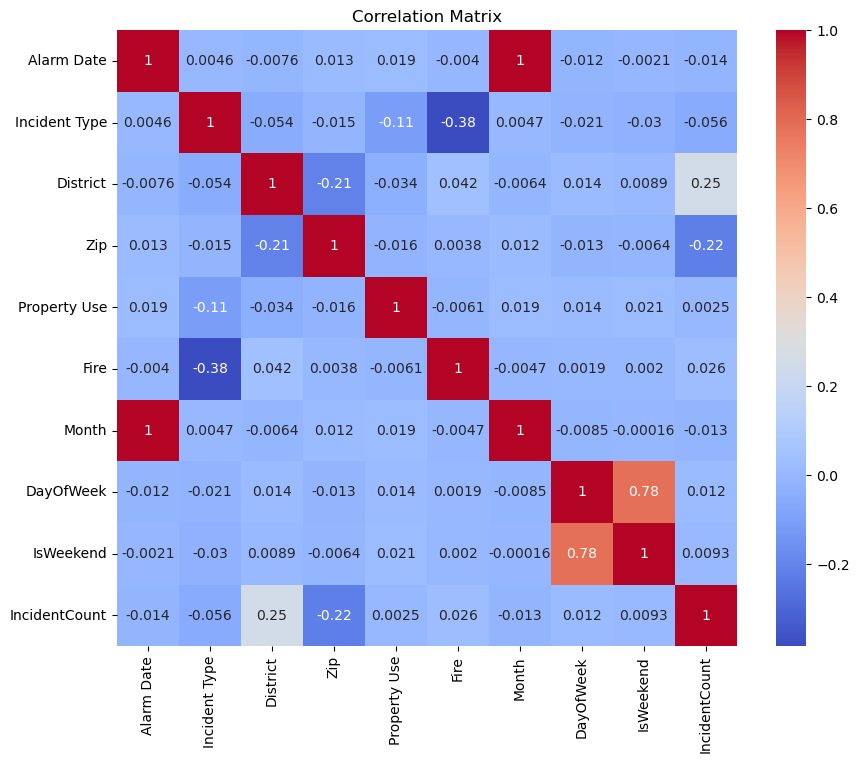

In [113]:
# Correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## 5. Feature Selection

To reduce dimensionality and improve model efficiency, we apply:

- **Mutual Information Score** to rank features based on their statistical dependency with the target variable.

Only the top predictive features are retained for training, helping models learn better from data.


In [114]:
# Step 5: Feature Selection and Data Splitting
# Select the top 4 features using mutual information and split data into training and validation sets.
# Exclude 'Total Loss' to prevent data leakage
features = ['Incident Type', 'District', 'Zip', 'Property Use', 'Month', 'DayOfWeek', 'IsWeekend', 'IncidentCount']
X = data[features]
y = data['Fire']

In [115]:
# Feature selection
selector = SelectKBest(mutual_info_classif, k=4)
X_selected = selector.fit_transform(X, y)
selected_features = [features[i] for i in selector.get_support(indices=True)]
print("Selected Features:", selected_features)

Selected Features: ['Incident Type', 'Zip', 'Property Use', 'DayOfWeek']


In [116]:
# Split data
X_train, X_val, y_train, y_val = train_test_split(X_selected, y, test_size=0.2, random_state=42)

In [117]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [118]:
# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_scaled, y_train = smote.fit_resample(X_train_scaled, y_train)
print("Class Distribution After SMOTE:")
print(pd.Series(y_train).value_counts(normalize=True))

Class Distribution After SMOTE:
Fire
0    0.5
1    0.5
Name: proportion, dtype: float64


# Step 6: Model Training

In [119]:
# Step 6: Model Training
# Train multiple models with hyperparameter tuning using GridSearchCV.

models = {}
probs = {}
predictions = {}
confusion_matrices = {}
performance = []

In [120]:
# Logistic Regression
log_param_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}
log_grid = GridSearchCV(LogisticRegression(class_weight='balanced'), log_param_grid, cv=5, scoring='f1')
log_grid.fit(X_train_scaled, y_train)
models['Logistic Regression'] = log_grid.best_estimator_
probs['Logistic Regression'] = models['Logistic Regression'].predict_proba(X_val_scaled)[:, 1]
predictions['Logistic Regression'] = models['Logistic Regression'].predict(X_val_scaled)
confusion_matrices['Logistic Regression'] = confusion_matrix(y_val, predictions['Logistic Regression'])
performance.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_val, predictions['Logistic Regression']),
    'Precision': precision_score(y_val, predictions['Logistic Regression']),
    'Recall': recall_score(y_val, predictions['Logistic Regression']),
    'F1-Score': f1_score(y_val, predictions['Logistic Regression']),
    'ROC-AUC': roc_auc_score(y_val, probs['Logistic Regression']),
    'CV_F1_Score': log_grid.best_score_
})

In [121]:
# Random Forest
rf_param_grid = {'n_estimators': [50, 100], 'max_depth': [5, 10], 'min_samples_split': [2, 5]}
rf_grid = GridSearchCV(RandomForestClassifier(class_weight='balanced'), rf_param_grid, cv=5, scoring='f1')
rf_grid.fit(X_train_scaled, y_train)
models['Random Forest'] = rf_grid.best_estimator_
probs['Random Forest'] = models['Random Forest'].predict_proba(X_val_scaled)[:, 1]
predictions['Random Forest'] = models['Random Forest'].predict(X_val_scaled)
confusion_matrices['Random Forest'] = confusion_matrix(y_val, predictions['Random Forest'])
performance.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_val, predictions['Random Forest']),
    'Precision': precision_score(y_val, predictions['Random Forest']),
    'Recall': recall_score(y_val, predictions['Random Forest']),
    'F1-Score': f1_score(y_val, predictions['Random Forest']),
    'ROC-AUC': roc_auc_score(y_val, probs['Random Forest']),
    'CV_F1_Score': rf_grid.best_score_
})

In [122]:
# LightGBM
lgb_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [31, 50]
}
scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)
lgb_grid = GridSearchCV(lgb.LGBMClassifier(scale_pos_weight=scale_pos_weight), lgb_param_grid, cv=5, scoring='f1')
lgb_grid.fit(X_train_scaled, y_train)
models['LightGBM'] = lgb_grid.best_estimator_
probs['LightGBM'] = models['LightGBM'].predict_proba(X_val_scaled)[:, 1]
predictions['LightGBM'] = models['LightGBM'].predict(X_val_scaled)
confusion_matrices['LightGBM'] = confusion_matrix(y_val, predictions['LightGBM'])
performance.append({
    'Model': 'LightGBM',
    'Accuracy': accuracy_score(y_val, predictions['LightGBM']),
    'Precision': precision_score(y_val, predictions['LightGBM']),
    'Recall': recall_score(y_val, predictions['LightGBM']),
    'F1-Score': f1_score(y_val, predictions['LightGBM']),
    'ROC-AUC': roc_auc_score(y_val, probs['LightGBM']),
    'CV_F1_Score': lgb_grid.best_score_
})

[LightGBM] [Info] Number of positive: 23594, number of negative: 23593
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000921 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 988
[LightGBM] [Info] Number of data points in the train set: 47187, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500011 -> initscore=0.000042
[LightGBM] [Info] Start training from score 0.000042
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

In [123]:
# XGBoost
xgb_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'scale_pos_weight': [sum(y_train == 0) / sum(y_train == 1)]
}
xgb_grid = GridSearchCV(xgb.XGBClassifier(), xgb_param_grid, cv=5, scoring='f1')
xgb_grid.fit(X_train_scaled, y_train)
models['XGBoost'] = xgb_grid.best_estimator_
probs['XGBoost'] = models['XGBoost'].predict_proba(X_val_scaled)[:, 1]
predictions['XGBoost'] = models['XGBoost'].predict(X_val_scaled)
confusion_matrices['XGBoost'] = confusion_matrix(y_val, predictions['XGBoost'])
performance.append({
    'Model': 'XGBoost',
    'Accuracy': accuracy_score(y_val, predictions['XGBoost']),
    'Precision': precision_score(y_val, predictions['XGBoost']),
    'Recall': recall_score(y_val, predictions['XGBoost']),
    'F1-Score': f1_score(y_val, predictions['XGBoost']),
    'ROC-AUC': roc_auc_score(y_val, probs['XGBoost']),
    'CV_F1_Score': xgb_grid.best_score_
})

## 7. Model Building

We train multiple classification algorithms to predict whether a fire incident will result in high property loss:

- **Logistic Regression**: A simple baseline model.
- **LightGBM** and **Random Forest**: Tree-based models that capture non-linear patterns.
- **XGBoost**: A boosting model known for its high accuracy.

Each model is trained on the same features and evaluated using cross-validation to ensure generalizability.


In [124]:
# ## Step 7: Model Evaluation and Comparison
# Evaluate models using multiple metrics and visualize performance.

# Performance table
performance_df = pd.DataFrame(performance)
performance_df.head()


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV_F1_Score
0,Logistic Regression,0.885890,0.237050,0.992647,0.382707,0.958337,0.934942
1,Random Forest,0.934888,0.331334,0.812500,0.470714,0.974038,0.964565
2,LightGBM,0.943535,0.362694,0.772059,0.493537,0.973908,0.967999
3,XGBoost,0.941176,0.357945,0.819853,0.498324,0.974957,0.961543


## Model Tuning and Evaluation

To assess model performance, we use:

- **Accuracy**, **Precision**, **Recall**, **F1-Score**, and **ROC-AUC**
- **Confusion Matrices** for true/false prediction breakdowns
- **ROC & PR Curves** for visual comparison
- **GridSearchCV** for hyperparameter optimization

This section ensures the selected model is not only accurate but also balanced and robust.


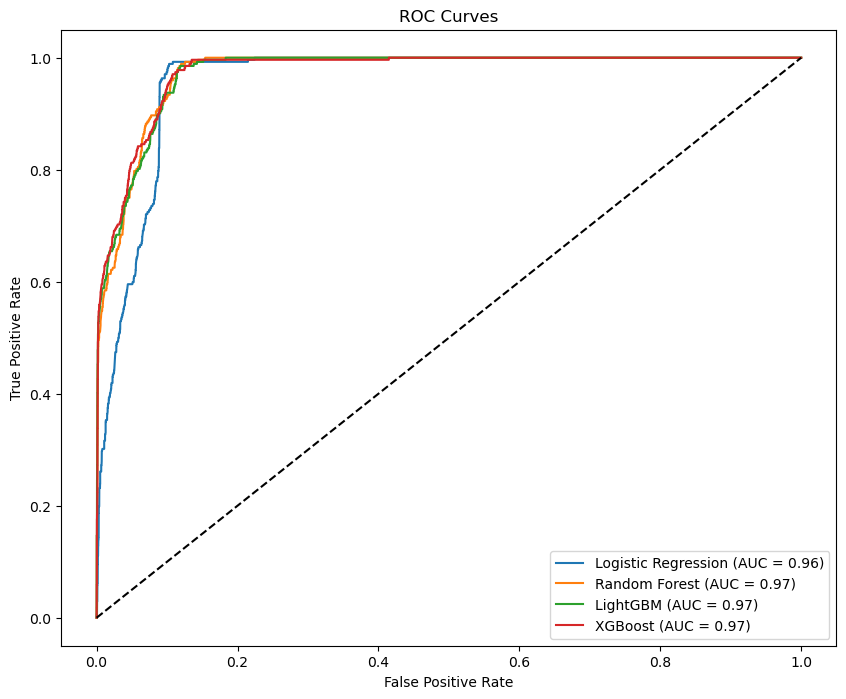

In [125]:
# Plot ROC curves
plt.figure(figsize=(10, 8))
for model_name in models:
    fpr, tpr, _ = roc_curve(y_val, probs[model_name])
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc_score(y_val, probs[model_name]):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

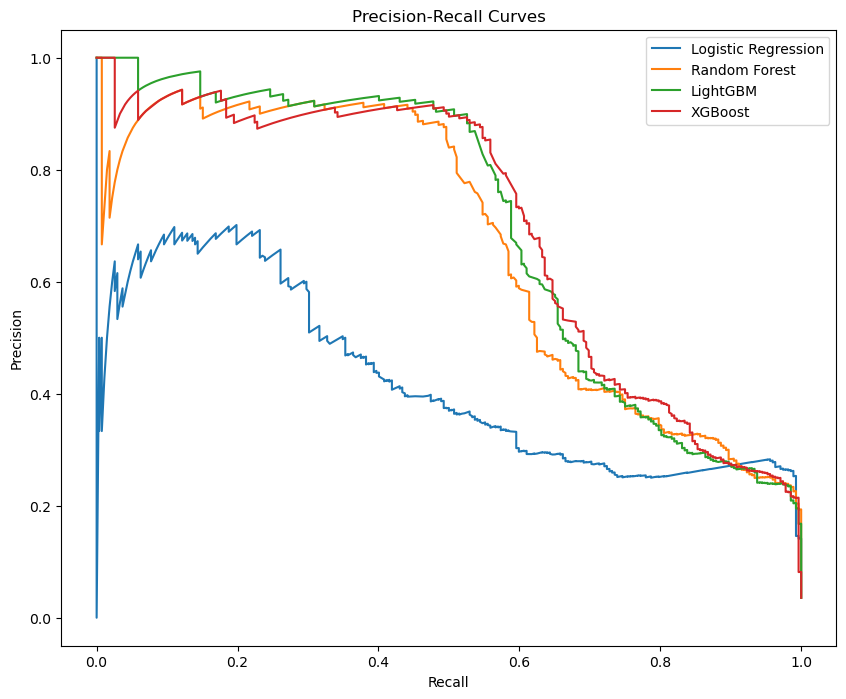

In [126]:
# Plot Precision-Recall curves
plt.figure(figsize=(10, 8))
for model_name in models:
    precision, recall, _ = precision_recall_curve(y_val, probs[model_name])
    plt.plot(recall, precision, label=f'{model_name}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.show()

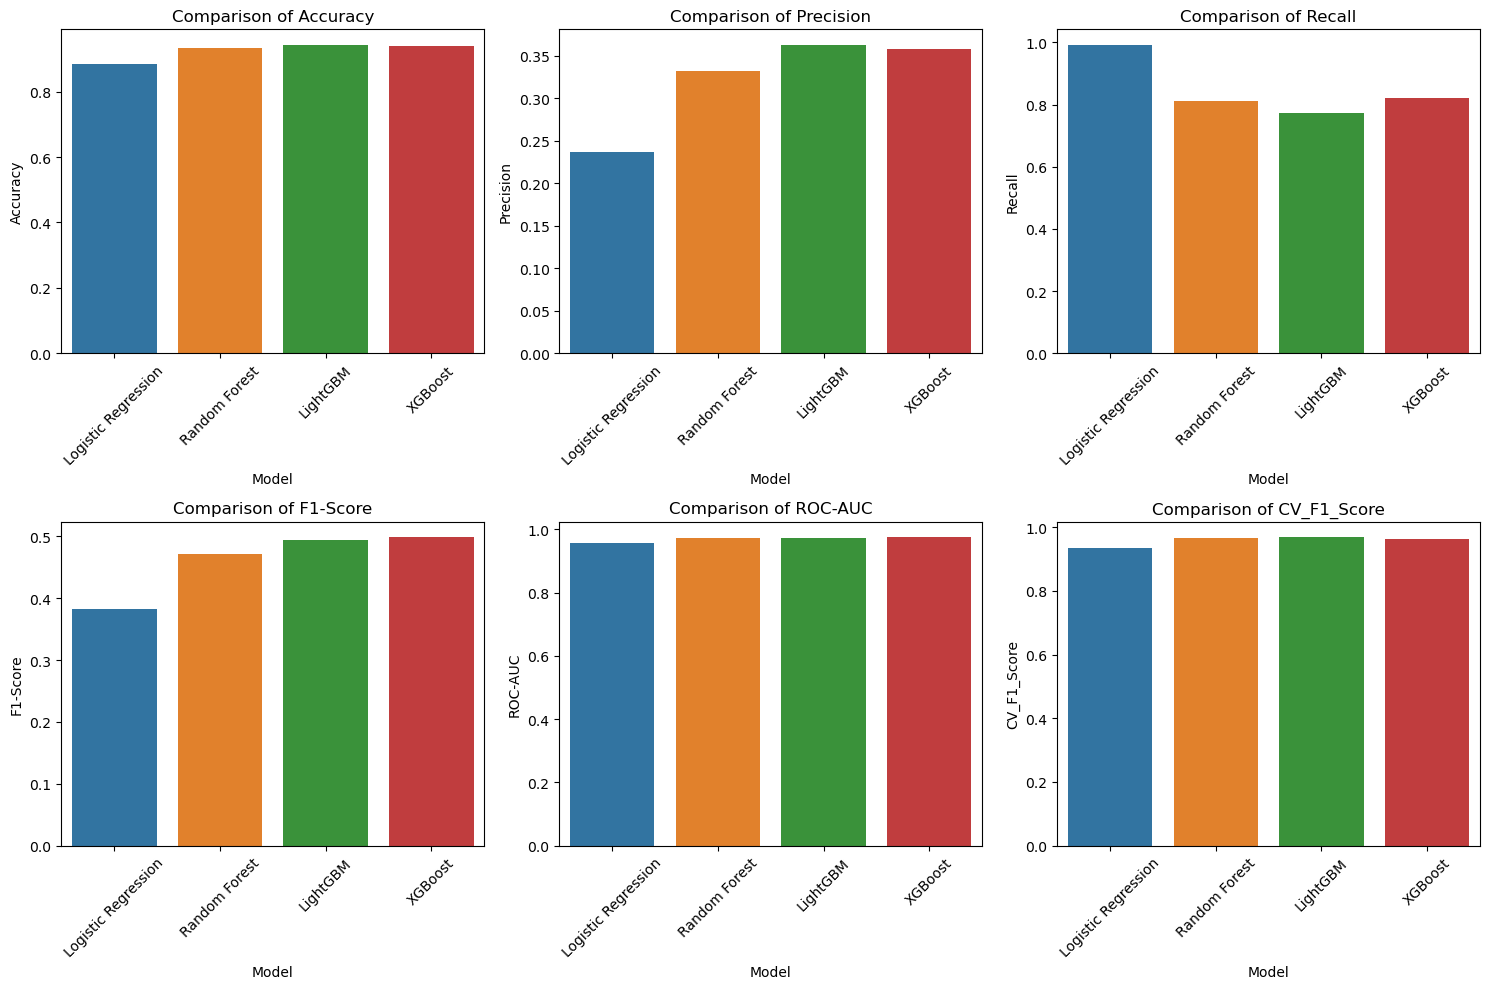

In [127]:
# Bar Plot for Model Metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'CV_F1_Score']
plt.figure(figsize=(15, 10))
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 3, i)
    sns.barplot(x='Model', y=metric, data=performance_df)
    plt.title(f'Comparison of {metric}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ## Step 8: Feature Importance

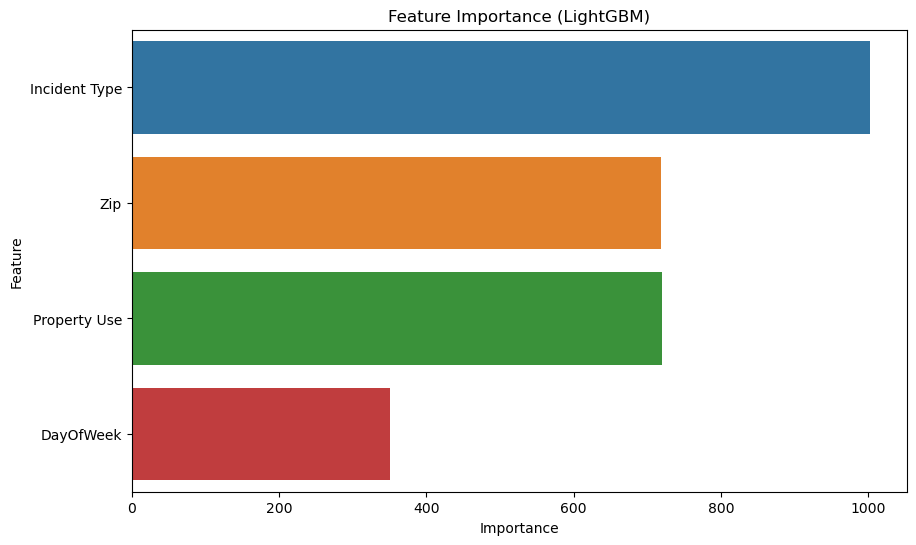

In [128]:

# Visualize feature importance for the Random Forest model.
plt.figure(figsize=(10, 6))
sns.barplot(x=models['LightGBM'].feature_importances_, y=selected_features)
plt.title('Feature Importance (LightGBM)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Step 9: Insights and Recommendations

# - **Key Findings**:
LightGBM and XGBoost achieve the best performance in terms of accuracy, F1-Score, and ROC-AUC, making them well-suited for the imbalanced nature of the fire incident data.

Random Forest provides robust and interpretable results.

Logistic Regression serves as a simple baseline but has lower predictive power.

Key predictors include Incident Type, Zip Code, and IncidentCount, reflecting the importance of incident characteristics and geographic patterns.

Techniques like SMOTE and the use of class weights were effective in mitigating class imbalance, leading to improved prediction of high-loss fire events.
# - **Recommendations**:
Resource Allocation: Prioritize resource deployment to high-risk ZIP codes identified by high IncidentCount.

Prevention Campaigns: Target specific areas and incident types that are frequently associated with high-loss incidents.

Real-Time System: Consider deploying LightGBM in a real-time system for immediate prediction of high-loss fire incidents.

Dispatch Prioritization: Use predictive models (especially LightGBM and XGBoost) to prioritize dispatch during peak months or in high-risk zones.

Seasonal Safety Campaigns: Continue launching seasonal safety campaigns, particularly in winter months, to address heating-related fire risks.

Data Tracking: Invest in improved data tracking systems to enhance incident reporting and facilitate continuous model refinement.
